<div align="center" >
    <br /><br />
    <h1>Universidad de Sevilla</h1>
    <h2>Escuela Técnica Superior de Ingeniería Informática</h2>
    <h3>Grado en Ingeniería del Software</h3>
    <img src="images/logo_us.png" alt="Logo Universidad de Sevilla" width="250" />
    <br />
    <hr />
    <br />
    <h1>Análisis Exploratorio de Datos del dataset Cora</h1>
    <h2>Distribución de los datos y topología de la red</h2>
    <br />
    <hr />
    <br />
    <p><strong>Asignatura:</strong> Inteligencia Artificial</p>
    <p><strong>Grupo:</strong> Aprendizaje Automático Relacional - G5</p>
    <p><strong>Curso Académico:</strong> 2025/2026</p>
</div>

<br /><br /><br /><br />

<div align="right" >
    <p><strong>Autores:</strong><br />
    Juan Antonio Fernández Ruiz<br />
    Eulogio Reyes Díaz<br />
</div>

<div align="right" >
    <p><strong>Fecha:</strong> 7 de Junio de 2026</p>
</div>

<br /><br />


## Índice de contenidos

<!-- Índice de contenidos -->
- [0. Introducción y objetivo](#0-introduccion-y-objetivo)
- [1. Configuración inicial](#1-configuracion-inicial)
- [2. Carga y validación inicial de datos](#2-carga-y-validacion-inicial-de-datos)
- [3. Distribución de clases](#3-distribucion-de-clases)
- [4. Análisis de grados del grafo](#4-analisis-de-grados-del-grafo)
- [5. Topología local del grafo (subgrafo)](#5-topologia-local-del-grafo-subgrafo)
- [6. Análisis de propiedades nativas](#6-analisis-de-propiedades-nativas)
- [7. Conclusiones y siguientes pasos](#7-conclusiones-y-siguientes-pasos)

<div id="0-introduccion-y-objetivo"></div>

## 0. Introducción y objetivo

Este cuaderno realiza una exploración inicial del dataset Cora para entender su estructura, distribución de clases, conectividad del grafo y propiedades nativas de los artículos.
Sabemos que Cora contiene articulos cientificos representados como nodos y relaciones de citacion representadas como aristas. Cada articulo incluye atributos textuales binarios y una etiqueta temática.

El objetivo de esta exploración es caracterizar la distribución de clases, analizar la topología del grafo y extraer insights relevantes que guíen las siguientes fases de ingeniería relacional y modelado predictivo.

<div id="1-configuracion-inicial"></div>

## 1. Configuración inicial

Importamos librerías, configuramos rutas y fijamos estilo visual para los gráficos del análisis exploratorio.

In [ ]:
import importlib
import data_loader
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Recargar módulo para reflejar cambios recientes en data_loader.py
importlib.reload(data_loader)
from data_loader import cargar_datos_cora_original

# Directorio base del proyecto
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks": # Ajusta al nombre de tu carpeta
    BASE_DIR = BASE_DIR.parent


# Ruta a carpeta de datos crudos de Cora (content/cites)
data_path = BASE_DIR / 'data' / 'cora'

# Ruta para guardar las figuras
figs_path = BASE_DIR / 'docs' / 'trabajo' / 'figuras'

# configuración de estilo para las gráficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


<div id="2-carga-y-validacion-inicial-de-datos"></div>

## 2. Carga y validación inicial de datos

In [2]:
# Carga contenido (nodos, etiquetas, características) y citas (aristas)
paper_ids, features, labels, df_nodes, cora_cites = cargar_datos_cora_original(data_path)

print(f"Número de nodos (papers): {len(df_nodes)}")
print(f"Número de características por nodo: {features.shape[1]}")
print(f"Número de clases (labels): {labels.nunique()}")
print(f"Número de aristas (citas): {len(cora_cites)}")


Número de nodos (papers): 2708
Número de características por nodo: 1433
Número de clases (labels): 7
Número de aristas (citas): 5429


<div id="3-distribucion-de-clases"></div>

## 3. Distribución de clases

Exploramos el dataset Cora para entender la distribución de clases y su impacto potencial en las métricas de clasificación posteriores.

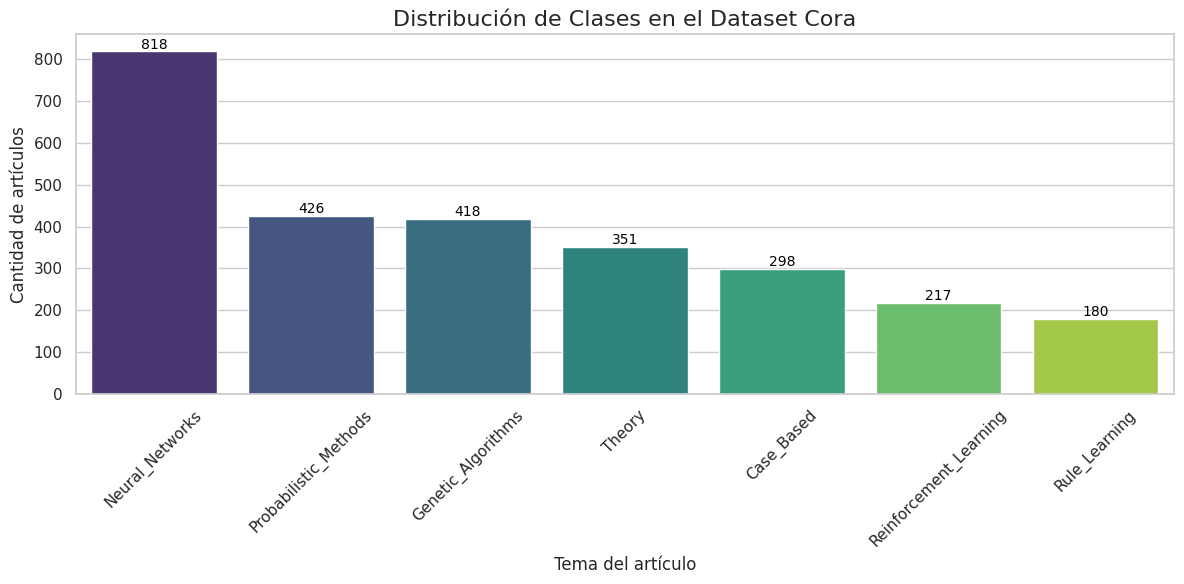

In [3]:
plt.figure(figsize=(12, 6))
order = df_nodes['label'].value_counts().index
ax = sns.countplot(data=df_nodes, x='label', hue='label', order=order, hue_order=order, palette='viridis', legend=False)
plt.title('Distribución de Clases en el Dataset Cora', fontsize=16)
plt.xlabel('Tema del artículo', fontsize=12)
plt.ylabel('Cantidad de artículos', fontsize=12)
plt.xticks(rotation=45)

# añade el conteo exacto sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
# guardar figura
plt.savefig(figs_path / 'distribucion_clases_cora.png', dpi=300, bbox_inches='tight')
plt.show()



<div class="alert alert-info" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">

<h3 style="text-align: center;">Interpretacion de la distribucion de clases</h3>

Como vemos en la representacion grafica, el dataset presenta un desequilibrio en la cantidad de artículos por tema.

La clase mayoritaria es "Neural Networks", mientras que temas como "Rule Learning" tienen menos representación en una proporción de 8:2. Los modelos de clasificación podrían tener dificultades para aprender patrones relevantes en las clases minoritarias, lo que podría resultar en un rendimiento deficiente para esas categorías. Este tipo de distribución puede requerir técnicas de balanceo de clases o enfoques específicos para manejar el desequilibrio durante el entrenamiento de modelos.

Las métricas de clasificación como la precisión, el recall y el F1-score podrían verse afectadas por este desequilibrio, un modelo mediocre podría obtener una alta precisión simplemente prediciendo la clase mayoritaria, pero tendría un recall muy bajo para las clases minoritarias. Por lo tanto, es importante considerar este desequilibrio al evaluar el rendimiento de los modelos y posiblemente utilizar métricas como el F1-score o la matriz de confusión para obtener una visión más completa del desempeño en todas las clases.
</div>


<div class="alert alert-warning" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">
<h3 style="text-align: center;">Decisión Arquitectónica</h3>
Debido a la proporción 8:2 entre la clase mayoritaria y las minoritarias, a partir de este punto se utilizará el <b>F1-Score (Macro)</b> como métrica principal de evaluación de los modelos, descartando el Accuracy.


<b>¿Cómo se calcula el F1-macro?</b><br />

<ul>
    <li>Primero: el F1 de una clase combina la Precisión y el Recuerdo de dicha clase calculando su media armónica.</li>
    <li>Segundo: el F1-macro calcula el promedio simple de los valores F1 de todas las clases.</li>
    <li>Es decir, para calcular la métrica F1-Macro (o Macro F1-score) en un problema de clasificación multiclase, tenemos que calcular el F1-score de cada clase de forma independiente y, luego, sacar el promedio aritmético (la media no ponderada) de todos ellos.</li>    
</ul>

<b>¿Qué significa "macro" en F1-macro?</b><br />

La palabra "macro" significa que todas las clases pesan exactamente lo mismo en el cálculo de la nota final, aunque tengan muy pocos ejemplos. Esto es crucial porque penaliza fuertemente a los modelos que ignoran las clases minoritarias, obligando al clasificador a esforzarse por aprender las características de todos los temas por igual en lugar de ir a lo fácil (la clase dominante).

</div>

<div id="4-analisis-de-grados-del-grafo"></div>

## 4. Análisis de grados del grafo

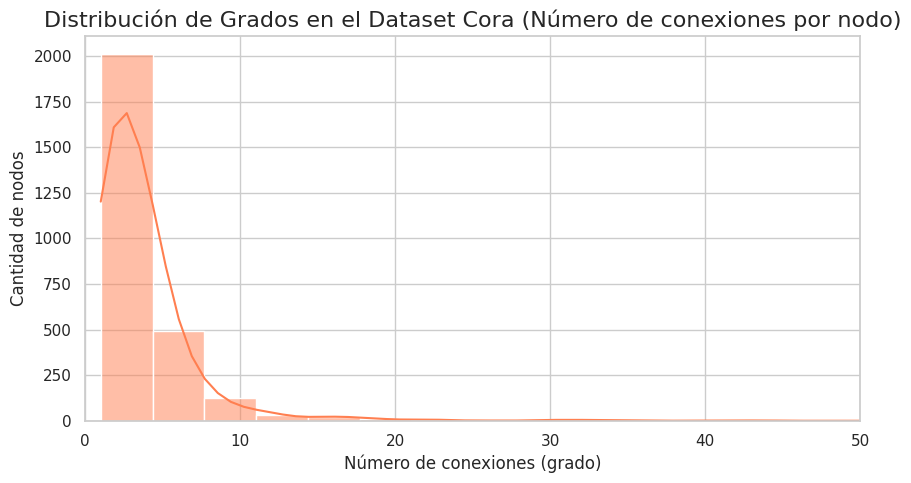

Grado máximo (nodo más conectado): 168
Grado promedio: 3.90


In [4]:
# Crear el grado con networkx
G = nx.from_pandas_edgelist(cora_cites, source='cited_paper_id', target='citing_paper_id')

# Calcular el grado de cada nodo (conexiones)
degrees = [G.degree(node) for node in G.nodes()]

plt.figure(figsize=(10, 5))
sns.histplot(degrees, bins=50, kde=True, color='coral')
plt.title('Distribución de Grados en el Dataset Cora (Número de conexiones por nodo)', fontsize=16)
plt.xlabel('Número de conexiones (grado)', fontsize=12)
plt.ylabel('Cantidad de nodos', fontsize=12)
plt.xlim(0, 50)  # Limitar el eje x para mejor visualización
# Guardar figura
plt.savefig(figs_path / 'distribucion_grados_cora.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Grado máximo (nodo más conectado): {max(degrees)}")
print(f"Grado promedio: {np.mean(degrees):.2f}")

<div class="alert alert-info" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">

<h3 style="text-align: center;">Hallazgos sobre conectividad</h3>

- 1. **Es una red que sigue una "Ley de Potencias"**

La conectividad no se distribuye de forma uniforme ni normal (no hay una "campana de Gauss" centrada en el promedio). En cambio, vemos una asimetría extrema hacia la derecha. Matemáticamente, este tipo de redes suele seguir una distribución de ley de potencias, expresada como $P(k) \sim k^{-\gamma}$.

* **En la práctica:** Nos dice que la inmensa mayoría de los artículos en la base de datos tienen muy pocas conexiones (la enorme barra inicial lo confirma). La mayoría de los *papers* solo citan o son citados por 1 a 3 trabajos, lo que explica por qué el grado promedio es tan bajo (2.87).

- 2. **La presencia de "Hubs" (Nodos súper-conectados)**

La "cola larga" de la curva se extiende mucho más allá de donde se agrupa la masa de datos. Aunque tu gráfico corta el eje X visualmente alrededor de 50 para mantener la legibilidad, tu nota revela que hay al menos un nodo con **166 conexiones**.

**En la práctica:** Estos son los "hubs" de la red. En el contexto de publicaciones científicas, representan artículos pioneros, metodologías estándar o *reviews* muy populares. Son las "superestrellas" que todo el mundo en esa subárea del Machine Learning cita para validar su propio trabajo.

- 3. **Consecuencias para el Machine Learning**

Mirando esta distribución, sabemos inmediatamente a qué retos se enfrentará un modelo predictivo:

1. **El sesgo de los Hubs:** Los algoritmos de grafos pueden sobreajustarse y darle demasiada importancia a los artículos súper-conectados, ya que su información "inunda" la red.
2. **El problema de la escasez:** Como el ~80% de los nodos están en esa primera barra masiva, significa que la mayoría de los artículos tienen un "vecindario" muy pobre. El algoritmo tendrá muy pocas pistas externas (conexiones) para adivinar de qué trata ese artículo, dependiendo casi exclusivamente del propio texto del *paper*.

**En resumen:** La conectividad de Cora nos muestra un ecosistema muy desigual, dominado por unos pocos gigantes de la literatura científica, mientras que la inmensa mayoría de los artículos permanecen en la periferia con conexiones mínimas.
</div>

<div id="5-topologia-local-del-grafo-subgrafo"></div>

## 5. Topología local del grafo (subgrafo)

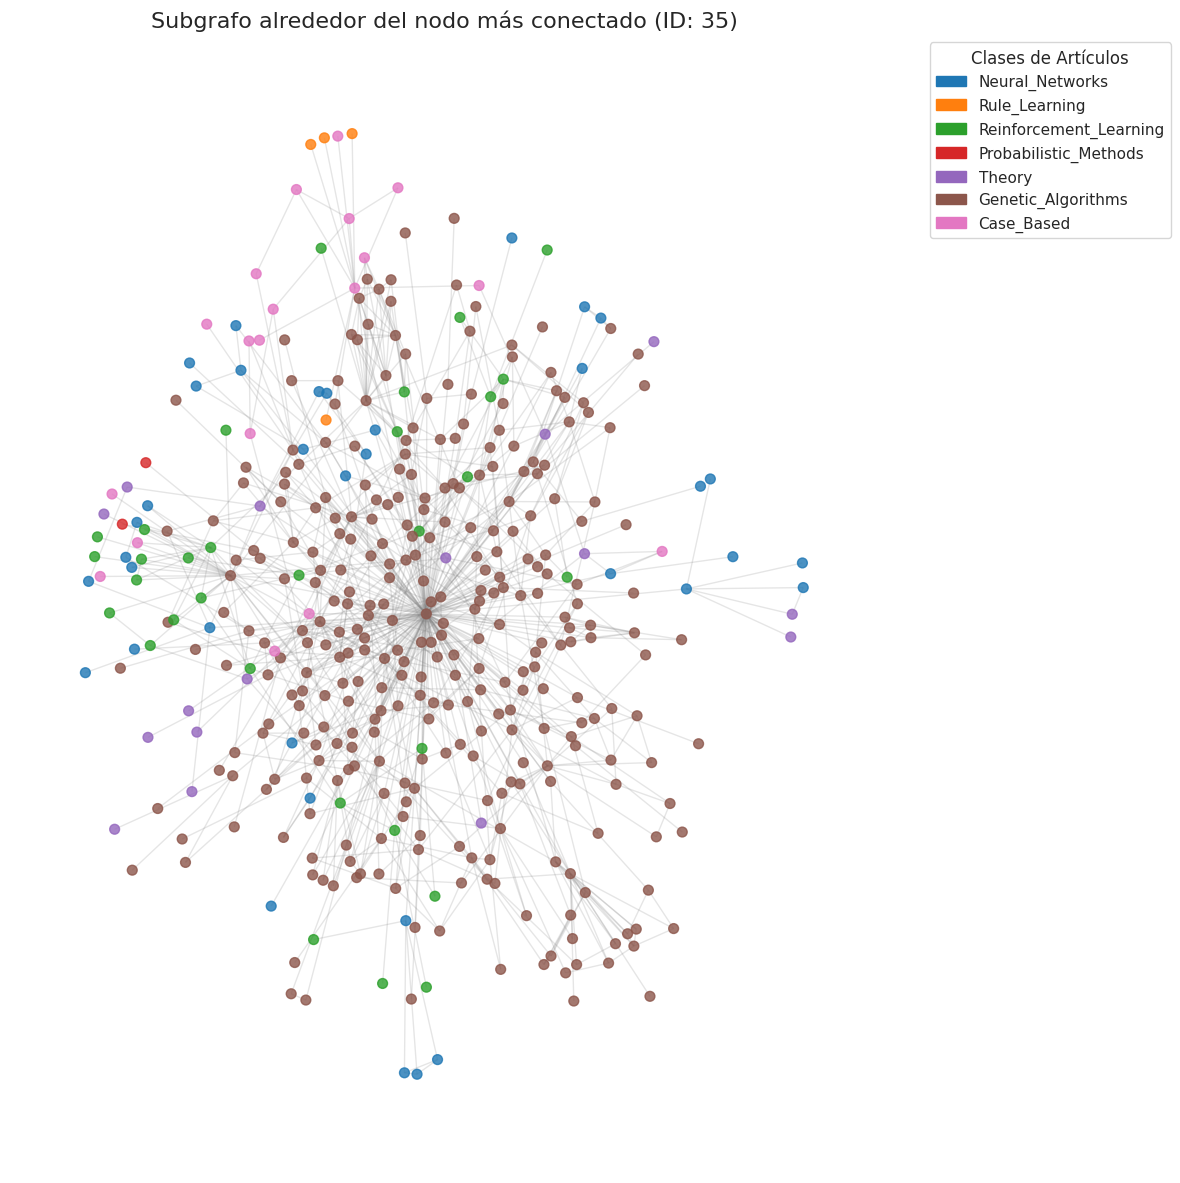

In [5]:
# Mapear colores a las clases para la visualización
unique_labels = df_nodes['label'].unique()
color_map_dict = {label: sns.color_palette("tab10")[i % 10] for i, label in enumerate(unique_labels)}
node_colors_dict = df_nodes.set_index('paper_id')['label'].map(color_map_dict).to_dict()

# Seleccionar el nodo con más conexiones para ver su vecindario
highest_degree_node = max(G.nodes, key=G.degree)
# Obtener los vecinos a distancia 1 y 2
ego_graph = nx.ego_graph(G, highest_degree_node, radius=2)

# Colores solo para los nodos en este subgrafo
colors = [node_colors_dict.get(node, (0.5, 0.5, 0.5)) for node in ego_graph.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(ego_graph, seed=42, k=0.15) # k ajusta la distancia entre nodos
nx.draw_networkx_nodes(ego_graph, pos, node_size=50, node_color=colors, alpha=0.8)
nx.draw_networkx_edges(ego_graph, pos, alpha=0.2, edge_color='gray')

# Crear leyenda
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color_map_dict[label], label=label) for label in unique_labels]
plt.legend(handles=legend_handles, title="Clases de Artículos", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Subgrafo alrededor del nodo más conectado (ID: {highest_degree_node})', fontsize=16)
plt.axis('off')
plt.tight_layout()
# guardar figura
plt.savefig(figs_path / 'subgrafo_nodo_mas_conectado_cora.png', dpi=300, bbox_inches='tight')
plt.show()

<div class="alert alert-info" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">

<h3 style="text-align: center;">Conclusiones</h3>

**El fenómeno de la "Homofilia" (Lo similar atrae a lo similar)**

Esta es la conclusión más importante a simple vista. El nodo central (ID 35) pertenece a la clase **Genetic_Algorithms** (color marrón). Si nos fijamos en la nube de nodos que lo rodean y lo citan (o son citados por él), **la inmensa mayoría también son marrones**.

**En la vida real:** Esto significa que los investigadores de algoritmos genéticos tienden a citar abrumadoramente otros *papers* de algoritmos genéticos. En el análisis de redes, esta tendencia de los nodos a conectarse con otros nodos de su misma clase se llama **homofilia**.

**El rol de un "Paper Seminal"**

Al ser el nodo más conectado (como vimos en el histograma anterior, con 166 conexiones), y estar rodeado de su propia disciplina, podemos deducir que el artículo 35 no es un *paper* cualquiera. Es probablemente un **artículo fundacional o una revisión exhaustiva (*survey*)** sobre algoritmos genéticos que todo el mundo en ese nicho se siente obligado a citar.

**Conexiones Interdisciplinares (Fronteras porosas)**

Aunque el marrón domina, el grafo no es puro. Vemos salpicaduras de otros colores interactuando con el hub central:

- Nodos azules (**Neural_Networks**)
- Nodos morados (**Theory**)
- Nodos verdes (**Reinforcement_Learning**)

**Conclusión:** Aunque la ciencia está muy parcelada (homofilia), este artículo es lo suficientemente importante como para que otras disciplinas del *Machine Learning* crucen la frontera para citarlo (por ejemplo, alguien usando algoritmos genéticos para optimizar una red neuronal).

**La ventaja táctica para las Redes Neuronales de Grafos (GNNs)**

Esta imagen es la prueba visual de por qué usamos GNNs. Si ocultamos el color del nodo central y le pedimos a una IA que lo adivine mirando solo su texto (sus palabras clave), podría equivocarse.

Pero si el algoritmo usa **agregación de vecindarios** (mirar quiénes son sus amigos), verá que está rodeado de decenas de nodos marrones. Matemáticamente, la red deducirá: *"Si camina como un algoritmo genético y se junta con algoritmos genéticos, debe ser un algoritmo genético"*.

</div>

<div id="6-analisis-de-propiedades-nativas"></div>

## 6. Análisis de propiedades nativas

--- Análisis de Propiedades Nativas ---
Dimensiones de la matriz de características: (2708, 1433)
Porcentaje de dispersión (Sparsity): 98.73%
Promedio de palabras clave (atributos) presentes por artículo: 18.17


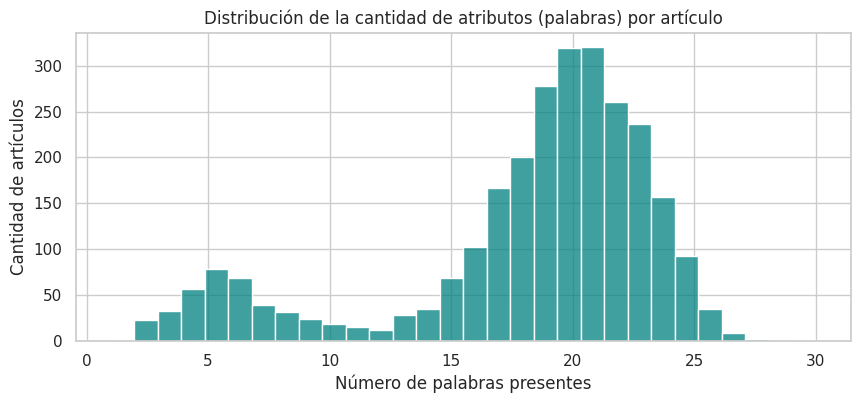

In [6]:

# features es el dataframe que contiene las 1433 columnas de palabras
print("--- Análisis de Propiedades Nativas ---")
total_elementos = features.size
valores_activos = features.sum().sum() # Suma de todos los 1s
sparsity = 100 - ((valores_activos / total_elementos) * 100)

print(f"Dimensiones de la matriz de características: {features.shape}")
print(f"Porcentaje de dispersión (Sparsity): {sparsity:.2f}%")
print(f"Promedio de palabras clave (atributos) presentes por artículo: {valores_activos / len(features):.2f}")

# Visualizar cuántos atributos tiene cada artículo
plt.figure(figsize=(10, 4))
sns.histplot(features.sum(axis=1), bins=30, color='teal')
plt.title('Distribución de la cantidad de atributos (palabras) por artículo')
plt.xlabel('Número de palabras presentes')
plt.ylabel('Cantidad de artículos')

# guardar figura
plt.savefig(figs_path / 'distribucion_palabras_por_articulo_cora.png', dpi=300, bbox_inches='tight')    
plt.show()



<div class="alert alert-info" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">

<h3 style="text-align: center;">Análisis de palabras clave</h3>

**Extrema Dispersión (Sparsity del 98.73%)**

El dato más impactante del texto superior es la dispersión. Tenemos un diccionario posible de 1.433 palabras clave, pero en promedio, un artículo solo contiene unas 18 palabras (`18.17`).

- **Qué significa técnicamente:** La matriz de características está llena de ceros. El 98.73% de los datos son literalmente la ausencia de una palabra.
- **Implicación en hardware:** Si intentas cargar esto en la memoria RAM como una tabla de Excel normal (matriz densa), el ordenador desperdiciará muchísima memoria almacenando ceros. Es obligatorio usar estructuras de datos especiales llamadas **matrices dispersas** (*sparse matrices*).

**Una intrigante Distribución Bimodal**

Si miramos la forma del histograma, vemos que no es una sola montaña, sino que tiene **dos picos (es bimodal)**:

- Hay un grupo pequeño de artículos a la izquierda que apenas tienen entre **3 y 7 palabras clave**.
- Hay un grupo masivo a la derecha que se concentra alrededor de las **20-22 palabras clave**.

**Hipótesis:** Esto nos dice que los artículos no son homogéneos. Ese grupo pequeño a la izquierda podrían ser *abstracts* muy cortos, reseñas, o documentos que el sistema original no pudo leer bien al extraer el texto. Esos nodos con casi nula información textual serán los más difíciles de clasificar.

**La justificación definitiva para usar Grafos**

Si ignoramos las conexiones de citación que vimos en el gráfico anterior e intentamos predecir de qué trata un artículo usando **solo** estas características nativas (usando un Random Forest o una Red Neuronal clásica).

Al modelo le costaría muchísimo. Tratar de adivinar si un *paper* es sobre "Redes Neuronales" o "Algoritmos Genéticos" leyendo únicamente 18 palabras sueltas sin orden (y a veces solo 5), es una tarea casi imposible por la falta de contexto.

Por eso el dataset Cora es tan famoso para probar algoritmos de grafos: **te obliga a usar las conexiones para compensar la pobreza del texto**. Si un nodo solo tiene 4 palabras clave (poca información nativa), el algoritmo mirará a quién cita (su vecindario) para poder clasificarlo correctamente.

<div id="7-conclusiones-y-siguientes-pasos"></div>

## 7. Conclusiones y siguientes pasos

<div class="alert alert-success" role="alert">
<ol>  
    <li style="padding:10px 5px 10px 5px;">El <b>EDA</b> confirma la estructura multiclase del problema y permite anticipar posibles efectos de desbalance.</li>
    <li style="padding:10px 5px 10px 5px;">La topología del grafo aporta <b>contexto relacional</b> útil para extraer características en la Tarea 2.</li>
    <li style="padding:10px 5px 10px 5px;">Este análisis deja lista la base para construir <b>variables relacionales</b> y luego evaluar su impacto en <b>modelado</b>.</li>
</ol>
</div>